<a href="https://colab.research.google.com/github/pyaramsravanthi/AI-Assisted-Threat-Detection-Dashboard/blob/main/Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Assisted Threat Detection Dashboard

## Prompt 1: Load Sample Threat Log Data

**Goal:** Simulate loading a dataset of security logs that would be used for threat detection. For demonstration purposes, we'll create a synthetic dataset.

In [20]:
import pandas as pd
import numpy as np


np.random.seed(42)
num_entries = 1000

data = {
    'timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=num_entries, freq='h')), # Hourly logs
    'source_ip': np.random.choice([f'192.168.1.{i}' for i in range(1, 255)], num_entries),
    'destination_ip': np.random.choice([f'10.0.0.{i}' for i in range(1, 255)], num_entries),
    'event_type': np.random.choice(['Login_Success', 'Login_Failure', 'File_Access', 'Network_Scan', 'Malware_Alert'], num_entries, p=[0.4, 0.2, 0.2, 0.1, 0.1]),
    'severity': np.random.choice(['Low', 'Medium', 'High', 'Critical'], num_entries, p=[0.3, 0.4, 0.2, 0.1]),
    'user_id': np.random.choice([f'user_{i}' for i in range(1, 50)], num_entries),
    'bytes_transferred': np.random.randint(100, 100000, num_entries)
}

df = pd.DataFrame(data)


df.loc[np.random.choice(df.index, 20, replace=False), 'event_type'] = 'Unusual_Activity'
df.loc[np.random.choice(df.index, 15, replace=False), 'severity'] = 'Critical'
df.loc[df['event_type'] == 'Unusual_Activity', 'bytes_transferred'] = np.random.randint(200000, 1000000, df[df['event_type'] == 'Unusual_Activity'].shape[0])


print("Threat log data loaded successfully. Displaying first 5 rows:")
display(df.head())

Threat log data loaded successfully. Displaying first 5 rows:


,timestamp,source_ip,destination_ip,event_type,severity,user_id,bytes_transferred
0,2023-01-01 00:00:00,192.168.1.103,10.0.0.157,Login_Failure,Medium,user_33,96462
1,2023-01-01 01:00:00,192.168.1.180,10.0.0.141,Login_Success,Low,user_49,52365
2,2023-01-01 02:00:00,192.168.1.93,10.0.0.46,Malware_Alert,Low,user_12,16161
3,2023-01-01 03:00:00,192.168.1.15,10.0.0.35,Malware_Alert,Critical,user_11,58326
4,2023-01-01 04:00:00,192.168.1.107,10.0.0.253,Unusual_Activity,Low,user_5,254225


## Prompt 2: Data Preprocessing

**Goal:** Clean and prepare the simulated threat log data for machine learning tasks. This includes handling data types and encoding categorical features.

In [2]:

print("\nInitial DataFrame Info:")
df.info()

categorical_cols = ['source_ip', 'destination_ip', 'event_type', 'severity', 'user_id']
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nDataFrame after one-hot encoding. Displaying first 5 rows:")
display(df_processed.head())


Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          1000 non-null   datetime64[ns]
 1   source_ip          1000 non-null   object        
 2   destination_ip     1000 non-null   object        
 3   event_type         1000 non-null   object        
 4   severity           1000 non-null   object        
 5   user_id            1000 non-null   object        
 6   bytes_transferred  1000 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 54.8+ KB

DataFrame after one-hot encoding. Displaying first 5 rows:


,timestamp,bytes_transferred,source_ip_192.168.1.10,source_ip_192.168.1.100,source_ip_192.168.1.101,source_ip_192.168.1.102,source_ip_192.168.1.103,source_ip_192.168.1.104,source_ip_192.168.1.105,source_ip_192.168.1.106,...,user_id_user_45,user_id_user_46,user_id_user_47,user_id_user_48,user_id_user_49,user_id_user_5,user_id_user_6,user_id_user_7,user_id_user_8,user_id_user_9
0,2023-01-01 00:00:00,96462,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2023-01-01 01:00:00,52365,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,2023-01-01 02:00:00,16161,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2023-01-01 03:00:00,58326,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2023-01-01 04:00:00,254225,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


## Prompt 3: Feature Engineering

**Goal:** Create new, potentially more informative features from existing ones, especially from the timestamp column, to aid in detecting time-based anomalies or patterns.

In [3]:

df_processed['hour_of_day'] = df_processed['timestamp'].dt.hour
df_processed['day_of_week'] = df_processed['timestamp'].dt.dayofweek
df_processed['month'] = df_processed['timestamp'].dt.month


df_processed = df_processed.drop('timestamp', axis=1)

print("\nDataFrame after feature engineering. Displaying first 5 rows:")
display(df_processed.head())


DataFrame after feature engineering. Displaying first 5 rows:


,bytes_transferred,source_ip_192.168.1.10,source_ip_192.168.1.100,source_ip_192.168.1.101,source_ip_192.168.1.102,source_ip_192.168.1.103,source_ip_192.168.1.104,source_ip_192.168.1.105,source_ip_192.168.1.106,source_ip_192.168.1.107,...,user_id_user_48,user_id_user_49,user_id_user_5,user_id_user_6,user_id_user_7,user_id_user_8,user_id_user_9,hour_of_day,day_of_week,month
0,96462,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,0,6,1
1,52365,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,1,6,1
2,16161,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,2,6,1
3,58326,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,3,6,1
4,254225,False,False,False,False,False,False,False,False,True,...,False,False,True,False,False,False,False,4,6,1


## Prompt 4: Exploratory Data Analysis (EDA)

**Goal:** Visualize the distribution of key features and identify potential patterns or anomalies before model training. For example, distribution of event types or severity levels.

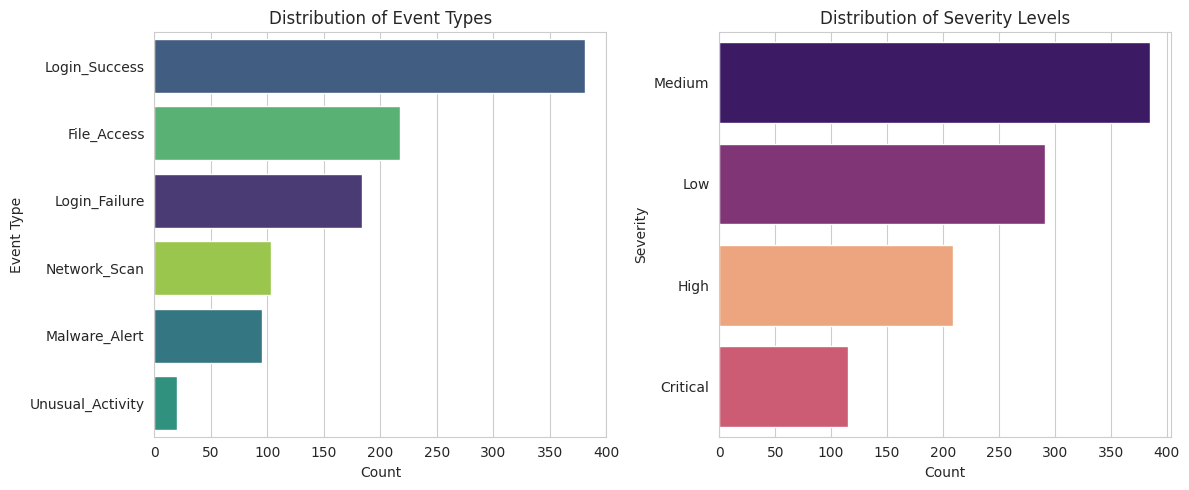

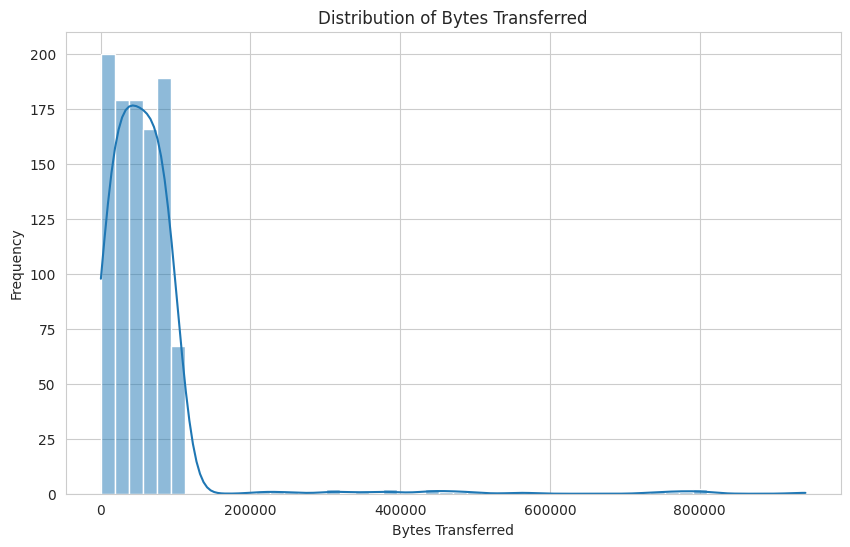

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, y='event_type', hue='event_type', order=df['event_type'].value_counts().index, palette='viridis', legend=False)
plt.title('Distribution of Event Types')
plt.xlabel('Count')
plt.ylabel('Event Type')

plt.subplot(1, 2, 2)
sns.countplot(data=df, y='severity', hue='severity', order=df['severity'].value_counts().index, palette='magma', legend=False)
plt.title('Distribution of Severity Levels')
plt.xlabel('Count')
plt.ylabel('Severity')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['bytes_transferred'], bins=50, kde=True)
plt.title('Distribution of Bytes Transferred')
plt.xlabel('Bytes Transferred')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_2026/3172803373.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='event_type', order=df['event_type'].value_counts().index, palette='viridis')
/tmp/ipykernel_2026/3172803373.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='severity', order=df['severity'].value_counts().index, palette='magma')


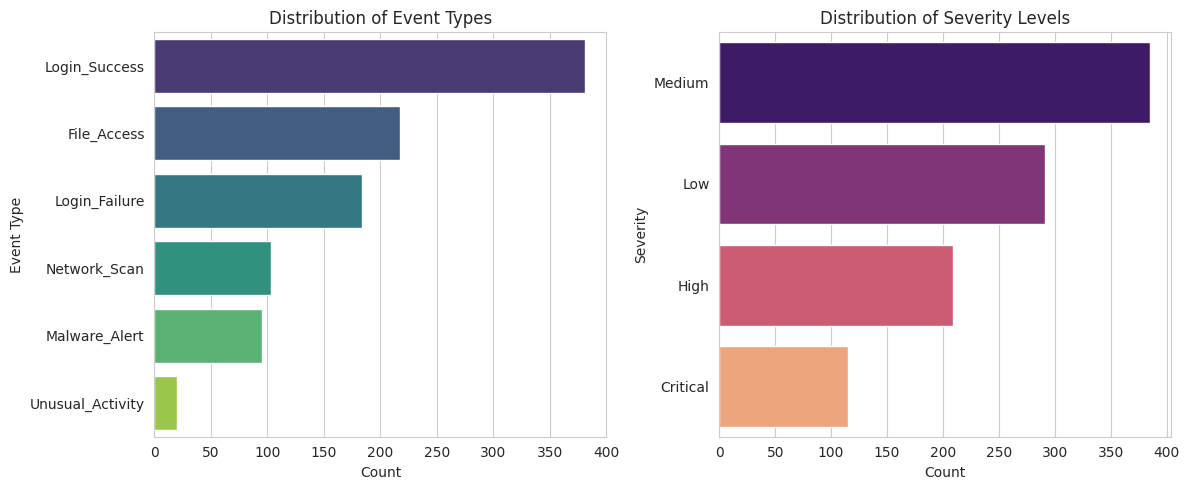

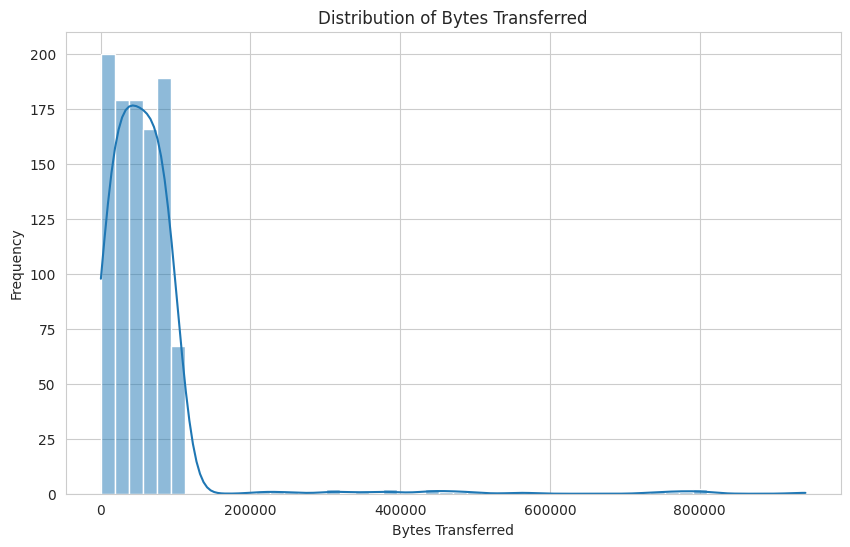

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, y='event_type', order=df['event_type'].value_counts().index, palette='viridis')
plt.title('Distribution of Event Types')
plt.xlabel('Count')
plt.ylabel('Event Type')

plt.subplot(1, 2, 2)
sns.countplot(data=df, y='severity', order=df['severity'].value_counts().index, palette='magma')
plt.title('Distribution of Severity Levels')
plt.xlabel('Count')
plt.ylabel('Severity')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['bytes_transferred'], bins=50, kde=True)
plt.title('Distribution of Bytes Transferred')
plt.xlabel('Bytes Transferred')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_2026/3624744172.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='event_type', order=df['event_type'].value_counts().index, palette='viridis')
/tmp/ipykernel_2026/3624744172.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='severity', order=df['severity'].value_counts().index, palette='magma')


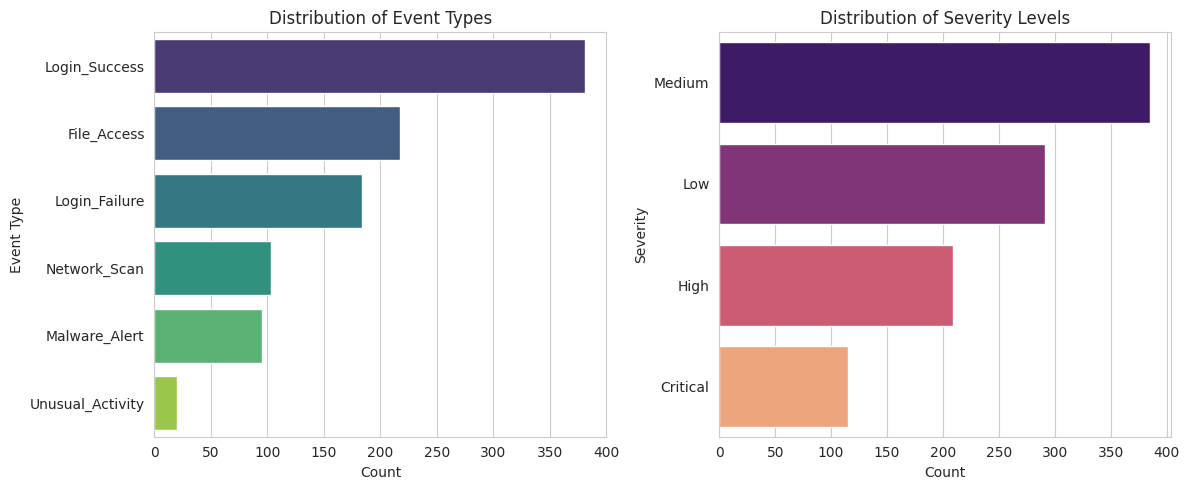

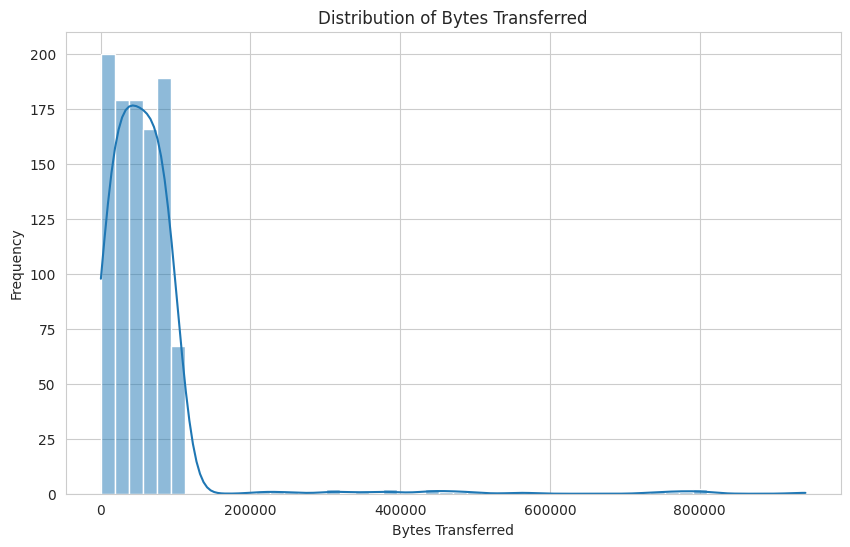

In [15]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, y='event_type', order=df['event_type'].value_counts().index, palette='viridis')
plt.title('Distribution of Event Types')
plt.xlabel('Count')
plt.ylabel('Event Type')

plt.subplot(1, 2, 2)
sns.countplot(data=df, y='severity', order=df['severity'].value_counts().index, palette='magma')
plt.title('Distribution of Severity Levels')
plt.xlabel('Count')
plt.ylabel('Severity')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['bytes_transferred'], bins=50, kde=True)
plt.title('Distribution of Bytes Transferred')
plt.xlabel('Bytes Transferred')
plt.ylabel('Frequency')
plt.show()

## Prompt 5: Anomaly Detection Model Training

**Goal:** Train an Isolation Forest model, a popular algorithm for anomaly detection, on the preprocessed data to identify unusual security events. We will use `bytes_transferred`, `hour_of_day`, and `day_of_week` for simplicity, but in a real scenario, all numerical features would be used.

In [13]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib # Import joblib to save the model and scaler

# Select numerical features for anomaly detection
features_for_model = ['bytes_transferred', 'hour_of_day', 'day_of_week']
X = df_processed[features_for_model]

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize and train Isolation Forest model
# contamination is the proportion of outliers in the data set and is used when fitting the model
model = IsolationForest(random_state=42, contamination=0.05)
model.fit(X_scaled)

# Save the trained model and scaler
joblib.dump(model, 'isolation_forest_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

# Predict anomaly scores and labels
df_processed['anomaly_score'] = model.decision_function(X_scaled)
df_processed['is_anomaly'] = model.predict(X_scaled) # -1 for anomalies, 1 for normal

# Map anomaly labels to readable format
df_processed['is_anomaly'] = df_processed['is_anomaly'].map({1: 0, -1: 1}) # 0 for normal, 1 for anomaly

print("Isolation Forest model trained and anomalies detected. Model and scaler saved.")
print("Displaying first 5 rows with anomaly info:")
display(df_processed[['bytes_transferred', 'hour_of_day', 'day_of_week', 'anomaly_score', 'is_anomaly']].head())

Isolation Forest model trained and anomalies detected. Model and scaler saved.
Displaying first 5 rows with anomaly info:


,bytes_transferred,hour_of_day,day_of_week,anomaly_score,is_anomaly
0,96462,0,6,-0.029323,1
1,52365,1,6,0.022755,0
2,16161,2,6,0.021692,0
3,58326,3,6,0.041256,0
4,254225,4,6,-0.069129,1


## Prompt 6: Model Evaluation (Anomaly Scores Visualization)

**Goal:** Visualize the distribution of anomaly scores to understand the model's output and how well it separates normal from anomalous events. Since we don't have true anomaly labels in this synthetic dataset, we'll focus on score distribution.

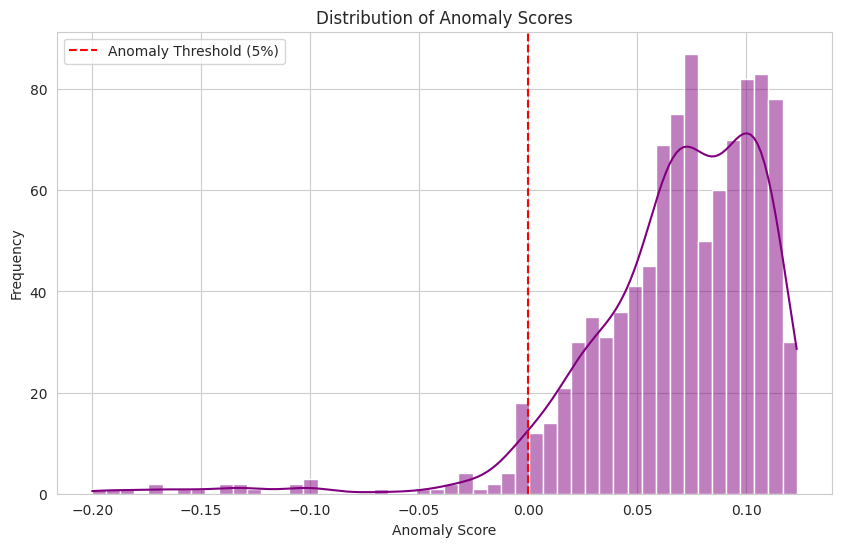

Number of detected anomalies: 50

Top 10 most anomalous entries (lowest scores):


,anomaly_score,is_anomaly,bytes_transferred,hour_of_day,day_of_week
505,-0.200019,1,941067,1,6
202,-0.192964,1,805398,10,0
38,-0.183979,1,799142,14,0
828,-0.171449,1,775648,12,5
90,-0.169216,1,765544,18,2
253,-0.157740,1,738938,13,2
715,-0.154678,1,473945,19,0
531,-0.141784,1,460102,3,0
162,-0.136347,1,440617,18,5
897,-0.129658,1,494478,9,1


In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df_processed['anomaly_score'], bins=50, kde=True, color='purple')
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.axvline(x=df_processed['anomaly_score'].quantile(0.05), color='red', linestyle='--', label='Anomaly Threshold (5%)')
plt.legend()
plt.show()

print(f"Number of detected anomalies: {df_processed['is_anomaly'].sum()}")
print("\nTop 10 most anomalous entries (lowest scores):")
display(df_processed.sort_values(by='anomaly_score').head(10)[['anomaly_score', 'is_anomaly'] + features_for_model])

## Prompt 7: Simulate Real-time Threat Prediction

**Goal:** Demonstrate how the trained model would predict anomalies on new, incoming security log data in a real-time scenario.

In [14]:
# Simulate Real-time Threat Prediction

import pandas as pd
import numpy as np
import joblib
import time

# -----------------------------
# Load the trained model and scaler
# -----------------------------
try:
    model = joblib.load('isolation_forest_model.pkl')
    scaler = joblib.load('feature_scaler.pkl')
except FileNotFoundError:
    print("Error: Model or scaler files not found. Please ensure Prompt 5 (Model Training) has been run.")
    # Exit or handle the error appropriately
    exit()

# Define the features the model expects (must be consistent with training)
features_for_model = ['bytes_transferred', 'hour_of_day', 'day_of_week']

# -----------------------------
# Function to generate a new simulated log entry
# -----------------------------
def generate_simulated_log():
    # Simulate realistic log data that aligns with the original df structure
    timestamp = pd.Timestamp.now()
    bytes_transferred = np.random.randint(100, 100000) # Normal range

    # Introduce some potential anomalies for demonstration
    if np.random.rand() < 0.1: # 10% chance of generating an unusual log
        bytes_transferred = np.random.randint(200000, 1000000) # High bytes
        # Could also simulate unusual hour/day combinations for anomaly

    log_data = {
        'timestamp': timestamp,
        'bytes_transferred': bytes_transferred,
        'hour_of_day': timestamp.hour,
        'day_of_week': timestamp.dayofweek
    }
    return pd.DataFrame([log_data])

# -----------------------------
# Real-time Prediction Simulation Loop
# -----------------------------
print("Real-time Threat Prediction Simulation Started...\n")

num_simulations = 5 # Run for a limited number of iterations for demonstration
for i in range(num_simulations):
    # Generate a new simulated log
    new_log_df = generate_simulated_log()

    # Prepare features for prediction
    X_new = new_log_df[features_for_model]
    X_new_scaled = scaler.transform(X_new)

    # Predict anomaly score and label
    anomaly_score = model.decision_function(X_new_scaled)[0]
    is_anomaly = model.predict(X_new_scaled)[0] # -1 for anomaly, 1 for normal

    # Display Result
    print(f"--- Simulation {i+1} ---")
    print(f"Timestamp: {new_log_df['timestamp'].iloc[0]}")
    print(f"Bytes Transferred: {new_log_df['bytes_transferred'].iloc[0]}")
    print(f"Anomaly Score: {anomaly_score:.4f}")
    if is_anomaly == -1:
        print("Prediction: 🚨 Anomaly Detected!")
    else:
        print("Prediction: ✅ Normal Traffic")

    print("-" * 30)

    # Wait before next log (simulates live monitoring)
    time.sleep(1)

print("Real-time Threat Prediction Simulation Finished.")

Real-time Threat Prediction Simulation Started...

--- Simulation 1 ---
Timestamp: 2026-07-02 13:22:55.134417
Bytes Transferred: 22498
Anomaly Score: 0.1076
Prediction: ✅ Normal Traffic
------------------------------
--- Simulation 2 ---
Timestamp: 2026-07-02 13:22:56.172631
Bytes Transferred: 18151
Anomaly Score: 0.1120
Prediction: ✅ Normal Traffic
------------------------------
--- Simulation 3 ---
Timestamp: 2026-07-02 13:22:57.204417
Bytes Transferred: 65240
Anomaly Score: 0.1169
Prediction: ✅ Normal Traffic
------------------------------
--- Simulation 4 ---
Timestamp: 2026-07-02 13:22:58.223064
Bytes Transferred: 5247
Anomaly Score: 0.0926
Prediction: ✅ Normal Traffic
------------------------------
--- Simulation 5 ---
Timestamp: 2026-07-02 13:22:59.241459
Bytes Transferred: 19743
Anomaly Score: 0.1111
Prediction: ✅ Normal Traffic
------------------------------
Real-time Threat Prediction Simulation Finished.


## Prompt 8: Dashboard Visualization - Threats Over Time

**Goal:** Visualize the number of detected anomalies over time to identify trends, spikes, and periods of increased threat activity. We need to re-incorporate the `timestamp` for this visualization.

/tmp/ipykernel_2026/3262838449.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  anomalies_over_time = df_viz[df_viz['is_anomaly'] == 1].groupby(pd.Grouper(key='timestamp', freq='H')).size().reset_index(name='num_anomalies')


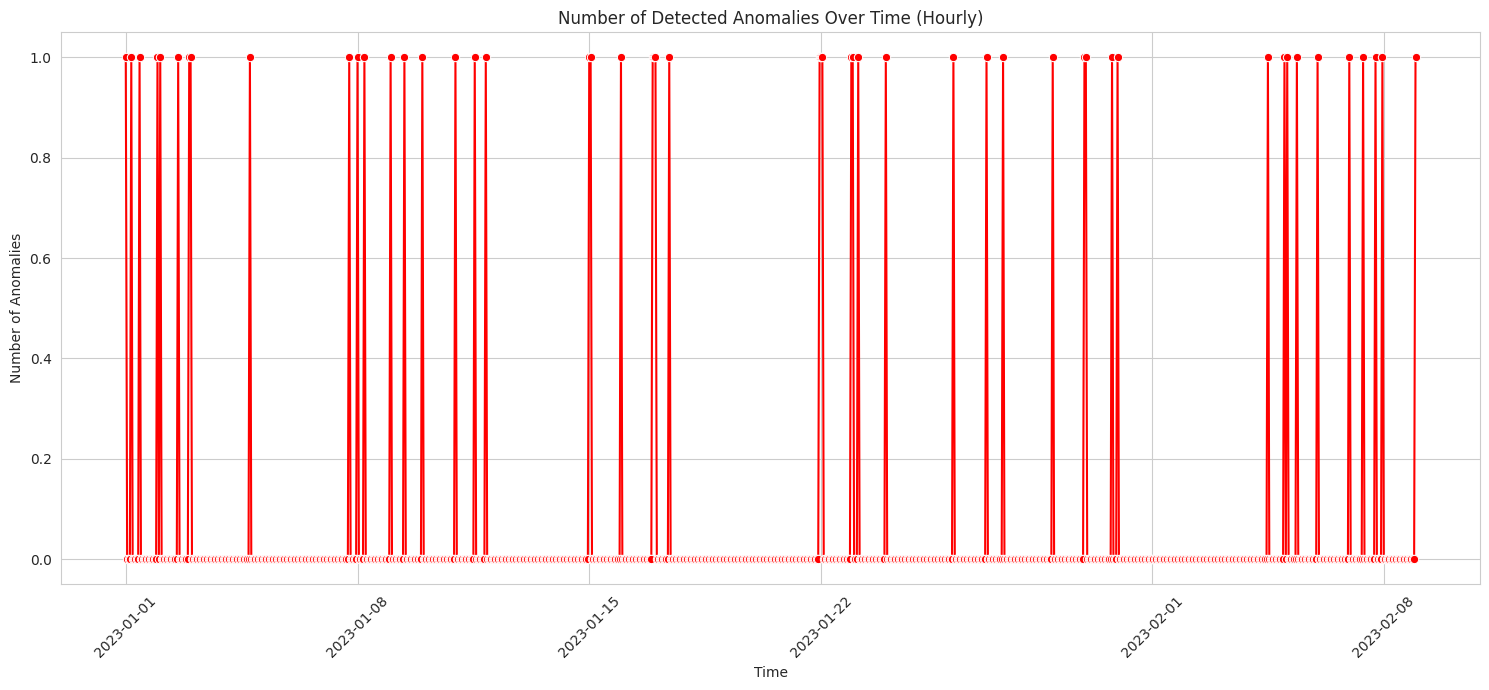

In [8]:

df_viz = df.copy()
df_viz['anomaly_score'] = model.decision_function(X_scaled)
df_viz['is_anomaly'] = model.predict(X_scaled)
df_viz['is_anomaly'] = df_viz['is_anomaly'].map({1: 0, -1: 1})

anomalies_over_time = df_viz[df_viz['is_anomaly'] == 1].groupby(pd.Grouper(key='timestamp', freq='H')).size().reset_index(name='num_anomalies')

plt.figure(figsize=(15, 7))
sns.lineplot(x='timestamp', y='num_anomalies', data=anomalies_over_time, marker='o', color='red')
plt.title('Number of Detected Anomalies Over Time (Hourly)')
plt.xlabel('Time')
plt.ylabel('Number of Anomalies')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Prompt 9: Dashboard Visualization - Top Threat Sources/Types

**Goal:** Create visualizations to quickly identify the most frequent sources of threats (e.g., source IPs) or types of anomalous events, helping security analysts prioritize their investigations.

In [ ]:
anomalous_df = df_viz[df_viz['is_anomaly'] == 1]

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
top_source_ips = anomalous_df['source_ip'].value_counts().head(10)
sns.barplot(x=top_source_ips.values, y=top_source_ips.index, palette='rocket')
plt.title('Top 10 Source IPs for Anomalies')
plt.xlabel('Number of Anomalies')
plt.ylabel('Source IP')

plt.subplot(1, 2, 2)
top_event_types = anomalous_df['event_type'].value_counts().head(10)
sns.barplot(x=top_event_types.values, y=top_event_types.index, palette='flare')
plt.title('Top 10 Anomalous Event Types')
plt.xlabel('Number of Anomalies')
plt.ylabel('Event Type')

plt.tight_layout()
plt.show()

## Prompt 10: Alerting Mechanism (Simulation)

**Goal:** Simulate a basic alerting mechanism that would trigger notifications for critical anomalies, demonstrating how the dashboard could actively inform security teams.

In [9]:
critical_anomaly_threshold = -0.15

critical_anomalies = df_viz[(df_viz['is_anomaly'] == 1) & (df_viz['anomaly_score'] < critical_anomaly_threshold)]

if not critical_anomalies.empty:
    print(f"\n*** CRITICAL THREAT ALERT! ***")
    print(f"{len(critical_anomalies)} critical anomalies detected. Immediate attention required.\n")
    for i, row in critical_anomalies.head(5).iterrows(): # Display top 5 for brevity
        print(f"  Timestamp: {row['timestamp']}")
        print(f"  Source IP: {row['source_ip']}")
        print(f"  Event Type: {row['event_type']}")
        print(f"  Severity: {row['severity']}")
        print(f"  Anomaly Score: {row['anomaly_score']:.4f}\n")
else:
    print("No critical threats detected at this time.")

print("\nAlerting mechanism simulation complete.")


*** CRITICAL THREAT ALERT! ***
7 critical anomalies detected. Immediate attention required.

  Timestamp: 2023-01-02 14:00:00
  Source IP: 192.168.1.49
  Event Type: Unusual_Activity
  Severity: High
  Anomaly Score: -0.1840

  Timestamp: 2023-01-04 18:00:00
  Source IP: 192.168.1.2
  Event Type: Unusual_Activity
  Severity: Medium
  Anomaly Score: -0.1692

  Timestamp: 2023-01-09 10:00:00
  Source IP: 192.168.1.253
  Event Type: Unusual_Activity
  Severity: High
  Anomaly Score: -0.1930

  Timestamp: 2023-01-11 13:00:00
  Source IP: 192.168.1.103
  Event Type: Unusual_Activity
  Severity: High
  Anomaly Score: -0.1577

  Timestamp: 2023-01-22 01:00:00
  Source IP: 192.168.1.54
  Event Type: Unusual_Activity
  Severity: Medium
  Anomaly Score: -0.2000


Alerting mechanism simulation complete.
